In [1]:
from src.measure_ir import *
import matplotlib.pyplot as plt
import numpy as np
from src.audio_device import AudioDevice
import soundfile as sf
from src.real_time import RealtimeFxLMS

In [2]:
arthur, fs = sf.read('data/arthur_clip_48k.wav')
ad = AudioDevice(fs)

In [3]:
error_ir, _ = measure_ir(ad)

In [4]:
ir_len = 128
panel_to_err_cm = 7
filter_order = 2 * ir_len
block_size=1024

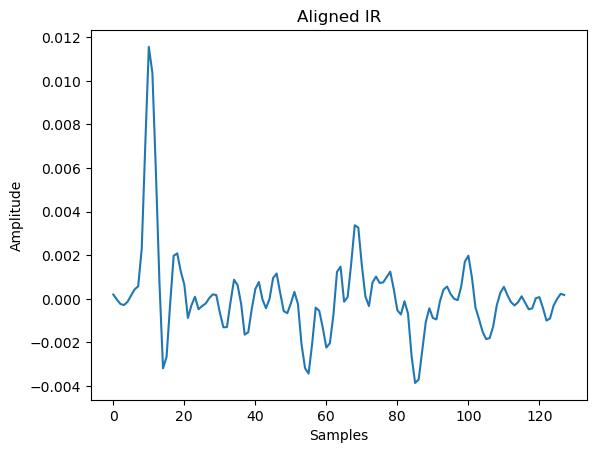

In [5]:
panel_ir = align_ir_by_distance(error_ir, panel_to_err_cm, ir_len)
plt.plot(panel_ir)

plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.title('Aligned IR')
plt.show()

In [6]:
arthur_repeated = np.tile(arthur, 20)
arthur.shape, arthur_repeated.shape


((238834,), (4776680,))

In [7]:
rt = RealtimeFxLMS(
    ad,
    source=arthur_repeated,
    ir=panel_ir,
    block_size=block_size,
    filter_order=filter_order,
)

In [8]:
rt.reset()
source_nc, cancel_nc, error_nc = rt.run(source_gain=1.0, cancel_gain=0.0)

In [10]:
step_fn = .01
# step_fn = lambda t: max(.1, 0.9 * np.exp(-t / 100))

rt.reset()
source, cancel, error = rt.run(step_fn, leak=1e-6, max_norm=1.0, source_gain=1.0, cancel_gain=0.15)

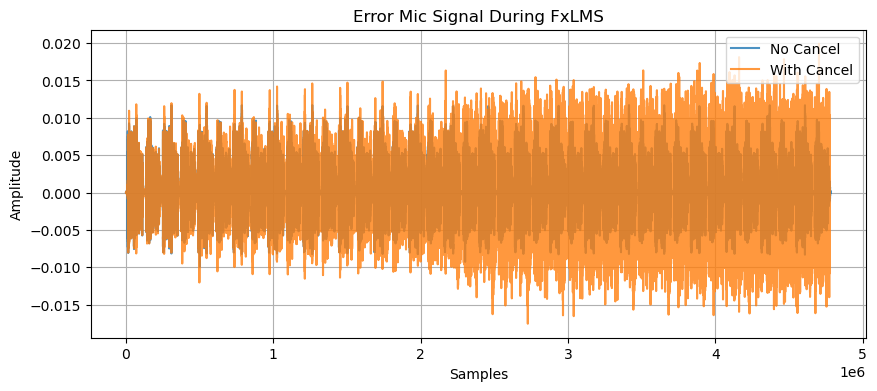

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(error_nc, alpha=0.8, label="No Cancel")
plt.plot(error, alpha=0.8, label="With Cancel")

plt.title("Error Mic Signal During FxLMS")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

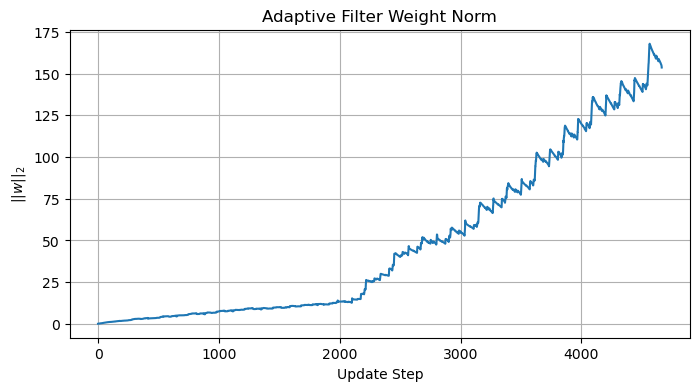

In [12]:
w_norms = np.asarray(rt.w_norm_log)

plt.figure(figsize=(8, 4))
plt.plot(w_norms)
plt.xlabel("Update Step")
plt.ylabel(r"$||w||_2$")
plt.title("Adaptive Filter Weight Norm")
plt.grid(True)
plt.show()

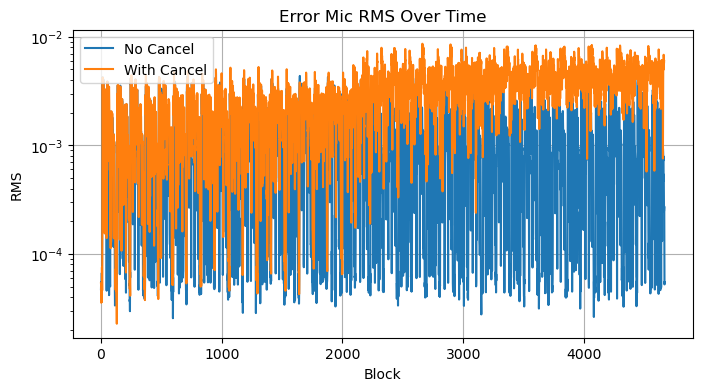

In [13]:
def block_rms(x, block=1024):
    n = len(x) // block
    x = x[:n * block].reshape(n, block)
    return np.sqrt(np.mean(x**2, axis=1))

err_rms_nc = block_rms(error_nc, block=block_size)
err_rms = block_rms(error, block=block_size)

plt.figure(figsize=(8, 4))
plt.plot(err_rms_nc, label="No Cancel")
plt.plot(err_rms, label="With Cancel")

plt.yscale("log")
plt.title("Error Mic RMS Over Time")
plt.xlabel("Block")
plt.ylabel("RMS")
plt.legend()
plt.grid(True)
plt.show()